In [21]:
# output
plm_metal_opt_result = "./fig/plm_metal_opt_result.pdf"

In [2]:
def get_config(file: str):
    import yaml

    lines = []
    with open(file, "r") as f:
        
        while True:
            line = f.readline()
            
            is_config_handled = False
            if line.strip().endswith("Config:"):
                while True:
                    l = f.readline()
                    l = l.strip("\n")
                    if len(l) != 0:
                        lines.append(l)
                    else:
                        break
                is_config_handled = True

            if is_config_handled:
                break
    return yaml.safe_load("\n".join(lines))

def get_perf(file: str, dataset_type: str):

    target_line = ""
    with open(file, "r") as f:
        
        while True:
            line = f.readline()
            is_perf_handled = False
            if line.strip().endswith("Performance on test dataset:"):

                if dataset_type == "metal":
                    target_line = f.readlines()[3].strip().removeprefix("1")
                elif dataset_type == "metal_type":
                    target_line = f.readlines()[15].strip().removeprefix("macro avg")
                elif dataset_type == "metal_group_type":
                    target_line = f.readlines()[7].strip().removeprefix("macro avg")

                is_perf_handled = True

            if is_perf_handled:
                break

    pre, recall, f1, _ = target_line.split()
    return {
        "precision": pre,
        "recall": recall,
        "f1-score": f1,
    }

In [3]:
from pathlib import Path

directory = Path('../tmp/logs')
files = []
for file in directory.rglob('*'):
    if file.is_file():
        files.append(file)

In [4]:
records = []

for i in files:
    cfg = get_config(i)
    dataset = cfg['dataset']['name']
    perf = get_perf(i, dataset)

    records.append({
        "model": cfg['model']['name'],
        "plm": cfg['plm']['name'],
        "dataset": dataset,
        **perf
    })

In [5]:
import pandas as pd

df = pd.DataFrame(records)
df = df.sort_values(by=['f1-score'])
df['f1-score'] = df['f1-score'].astype(float)

In [6]:
def select_plm(df: pd.DataFrame, dataset_type: str, discard_strut: bool = True, only_max: bool = True):
    df_ = df[df['dataset'] == dataset_type]
    if only_max:
        idx = df_.groupby('plm')['f1-score'].idxmax()
        result = df_.loc[idx].reset_index(drop=True).sort_values(by=['f1-score'])
    else:
        result = df_.reset_index(drop=True).sort_values(by=['f1-score'])
    if discard_strut:
        result = result[result['plm'].map(lambda x: x not in {"prosst-2048", "saprot-650M-PDB", "saprot-650M-AF2"})]
    return result

In [6]:
df_metal = select_plm(df, "metal")
df_metal = pd.concat((df_metal, pd.DataFrame([{"plm": "MetalNet2", "f1-score": 0.7577}])), ignore_index=True)
df_metal

,model,plm,dataset,precision,recall,f1-score
0,ag,esm2-150M,metal,0.8494,0.7400,0.7909
1,ag,esm2-650M,metal,0.8390,0.7496,0.7918
2,svm,prott5-xl,metal,0.8699,0.7426,0.8012
3,svm,esm2-3B,metal,0.8718,0.7415,0.8014
4,svm,ankh-base,metal,0.8492,0.7648,0.8048
5,svm,ankh-large,metal,0.8526,0.7708,0.8097
6,NaN,MetalNet2,NaN,NaN,NaN,0.7577


In [7]:
df_metal = select_plm(df, "metal", only_max=False)
df_metal = df_metal.sort_values(by=['model', 'plm'])
df_metal

rows = ['AutoGluon', 'Neural network', 'SVM']
columns = ['Ankh-base', 'Ankh-large', 'ESM2-150M', 'ESM2-3B', 'ESM2-650M', 'ProtT5-XL-UniRef50']
values = df_metal['f1-score'].to_numpy().reshape(3, 6)
values

,model,plm,dataset,precision,recall,f1-score
17,ag,ankh-base,metal,0.8800,0.7365,0.8019
18,ag,ankh-large,metal,0.8702,0.7481,0.8046
12,ag,esm2-150M,metal,0.8494,0.7400,0.7909
6,ag,esm2-3B,metal,0.8481,0.7047,0.7698
13,ag,esm2-650M,metal,0.8390,0.7496,0.7918
14,ag,prott5-xl,metal,0.8650,0.7345,0.7944
3,nn,ankh-base,metal,0.7953,0.6981,0.7435
4,nn,ankh-large,metal,0.7981,0.7163,0.7550
5,nn,esm2-150M,metal,0.8143,0.7173,0.7627
8,nn,esm2-3B,metal,0.8528,0.7254,0.7840


array([[0.8019, 0.8046, 0.7909, 0.7698, 0.7918, 0.7944],
       [0.7435, 0.755 , 0.7627, 0.784 , 0.7838, 0.7897],
       [0.8048, 0.8097, 0.7893, 0.8014, 0.7891, 0.8012]])

<Axes: >

[Text(0.5, 0, 'Ankh-base'),
 Text(1.5, 0, 'Ankh-large'),
 Text(2.5, 0, 'ESM2-150M'),
 Text(3.5, 0, 'ESM2-3B'),
 Text(4.5, 0, 'ESM2-650M'),
 Text(5.5, 0, 'ProtT5-XL-UniRef50')]

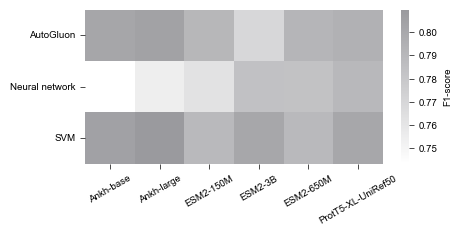

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

cmap = LinearSegmentedColormap.from_list('custom_gray', ['white', '#9A9A9E'])
fig, ax = plt.subplots(figsize=(4.8, 2))
sns.heatmap(values,
            cmap=cmap,
            xticklabels=columns,
            yticklabels=rows,
            cbar_kws={'label': 'F1-score'}
           )
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
plt.savefig(plm_metal_opt_result, bbox_inches="tight", transparent=True)